<h3><b>RNA Regression utilizando biblioteca Pytorch</b></h3>
<h4><b>Experimento utilizando técnica cross-validation combinada com tuning de hiperparâmetros.</b></h4>
<p>Utilizaremos base de dados grande.</p>

In [153]:
import pandas as pd
import numpy as np
import copy

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, Subset

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score

import matplotlib.pyplot as plt

In [154]:
torch.manual_seed(123)

<h4><b>Carregando dados</b></h4>

In [155]:
path = '/media/marcos/500GB/00_datasets/post_processing/post_processing_dataset.csv'
df = pd.read_csv(path)

In [156]:
df = df[[
    'line_category',
    'line_color',
    'station_initial_latitude',
    'station_initial_longitude',
    'station_final_latitude',
    'station_final_longitude',
    'distance',
    'average_speed_kh',
    'duration'
]]

<h4><b>Atribuindo valores as variáveis X e y</b></h4>

In [157]:
X = df.iloc[:,0:8].values
y = df.iloc[:,8].values

In [142]:
X.shape

(12372, 8)

In [143]:
y.shape

(12372,)

<h4><b>Convertendo em tensores Pytorch</b></h4>
<p>view: Redefine as dimensões</p>

In [158]:
X = torch.tensor(X, dtype=torch.float)
y = torch.tensor(y, dtype=torch.float).view(-1,1)

<h4><b>Divisão em treino e teste</b></h4>

In [159]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

<h4><b>Construção do modelo da rede neural</b></h4>
<p>Efetuamos este cálculo visando inicializar a quantidade de neurônios nas camadas ocultas da rede neural.</p>
<p>(entradas + saidas) / 2</p>

<ul>
    <li>Entrada: 8</li>
    <li>Camada oculta: 4 neurônios</li>
    <li>Camada oculta: 4 neurônios</li>
    <li>Camada de saída 1 neurônios</li>
</ul>

In [160]:
regressor = nn.Sequential(
    nn.Linear(8, 4),
    nn.ReLU(),
    nn.Linear(4, 4),
    nn.ReLU(),
    nn.Linear(4, 1)
)

<h4><b>Configurando Hiperparâmetros</b></h4>

In [ ]:
# Parâmetros encontrados pela Grid Search
# {'batch_size': 64,
#  'criterion': torch.nn.modules.loss.SmoothL1Loss,
#  'max_epochs': 100,
#  'optimizer__lr': 0.01}

In [161]:
epochs = 450
batch_size = 64
learning_rate = 0.001
criterion = torch.nn.SmoothL1Loss(reduction='mean')
optimizer = optim.Adam(regressor.parameters(), lr=learning_rate)

<h4><b>Inicializando variáveis responsáveis de armazenar histórico das métricas</b></h4>

In [162]:
loss_list = []
mae_list = []
mse_list = []
rmse_list = []
r2_list = []

In [163]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
dataset = TensorDataset(X_train, y_train)

In [164]:
mae_train_per_fold = []
mae_test_per_fold = []
mse_train_per_fold = []
mse_test_per_fold = []
rmse_train_per_fold = []
rmse_test_per_fold = []
r2_train_per_fold = []
r2_test_per_fold = []

In [165]:
for fold, (train_idx, val_idx) in enumerate(kf.split(dataset), start=1):
    print(f"\nTreinando Fold {fold}...")

    # Criando subconjuntos de treino e validação
    train_subsampler = Subset(dataset, train_idx)
    val_subsampler = Subset(dataset, val_idx)

    train_loader = DataLoader(train_subsampler, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_subsampler, batch_size=batch_size, shuffle=False)

    # Criando um novo modelo para cada fold (garante que os pesos não sejam reutilizados)
    model = copy.deepcopy(regressor)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    # Loop de treinamento por épocas
    for epoch in range(epochs):
        model.train()
        running_loss, running_mae, running_mse = 0.0, 0.0, 0.0

        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)

            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            running_mae += F.l1_loss(outputs, labels, reduction='sum').item()
            running_mse += F.mse_loss(outputs, labels, reduction='sum').item()

        # Calculando métricas de treino da época
        mae_train_epoch = running_mae / len(train_loader.dataset)
        mse_train_epoch = running_mse / len(train_loader.dataset)
        rmse_train_epoch = np.sqrt(mse_train_epoch)

    # Avaliação no conjunto de validação (teste do fold)
    model.eval()
    with torch.no_grad():
        val_inputs, val_labels = val_loader.dataset[:]
        val_outputs = model(val_inputs)

        mae_test = F.l1_loss(val_outputs, val_labels, reduction='mean').item()
        mse_test = F.mse_loss(val_outputs, val_labels, reduction='mean').item()
        rmse_test = np.sqrt(mse_test)

        val_labels_np = val_labels.cpu().numpy().flatten()
        val_outputs_np = val_outputs.cpu().numpy().flatten()

        r2_test = r2_score(val_labels_np, val_outputs_np)

    # Cálculo do R² de treino
    with torch.no_grad():
        train_inputs, train_labels = train_loader.dataset[:]
        train_outputs = model(train_inputs)

        train_labels_np = train_labels.cpu().numpy().flatten()
        train_outputs_np = train_outputs.cpu().numpy().flatten()

        r2_train = r2_score(train_labels_np, train_outputs_np)

    # Armazena os resultados do fold
    mae_train_per_fold.append(mae_train_epoch)
    mae_test_per_fold.append(mae_test)
    mse_train_per_fold.append(mse_train_epoch)
    mse_test_per_fold.append(mse_test)
    rmse_train_per_fold.append(rmse_train_epoch)
    rmse_test_per_fold.append(rmse_test)
    r2_train_per_fold.append(r2_train)
    r2_test_per_fold.append(r2_test)

    # Garante que não ultrapasse 5 folds
    if fold == 5:
        break

# Cálculo da média e desvio padrão de cada métrica
def mean_std(metric_list):
    return np.mean(metric_list), np.std(metric_list)

mae_train_avg, mae_train_std = mean_std(mae_train_per_fold)
mae_test_avg, mae_test_std = mean_std(mae_test_per_fold)
mse_train_avg, mse_train_std = mean_std(mse_train_per_fold)
mse_test_avg, mse_test_std = mean_std(mse_test_per_fold)
rmse_train_avg, rmse_train_std = mean_std(rmse_train_per_fold)
rmse_test_avg, rmse_test_std = mean_std(rmse_test_per_fold)
r2_train_avg, r2_train_std = mean_std(r2_train_per_fold)
r2_test_avg, r2_test_std = mean_std(r2_test_per_fold)

# Exibição dos resultados
print("\nResultados da Cross-Validation:")
print("-" * 50)
print(f"MAE Treino: {mae_train_avg:.4f} ± {mae_train_std:.4f}")
print(f"MAE Teste:  {mae_test_avg:.4f} ± {mae_test_std:.4f}")
print("-" * 50)
print(f"MSE Treino: {mse_train_avg:.4f} ± {mse_train_std:.4f}")
print(f"MSE Teste:  {mse_test_avg:.4f} ± {mse_test_std:.4f}")
print("-" * 50)
print(f"RMSE Treino: {rmse_train_avg:.4f} ± {rmse_train_std:.4f}")
print(f"RMSE Teste:  {rmse_test_avg:.4f} ± {rmse_test_std:.4f}")
print("-" * 50)
print(f"R² Treino: {r2_train_avg:.4f} ± {r2_train_std:.4f}")
print(f"R² Teste:  {r2_test_avg:.4f} ± {r2_test_std:.4f}")

mae_test_first_5_folds = mae_test_per_fold[:5]

# Calculando a média da MAE apenas para os 5 primeiros folds
mae_test_avg_5_folds = np.mean(mae_test_first_5_folds)

# Exibindo a MAE de cada um dos 5 primeiros folds
print("\nMAE dos 5 primeiros folds no conjunto de teste:")
for i, mae in enumerate(mae_test_first_5_folds):
    print(f"Fold {i+1}: {mae:.4f}")


Treinando Fold 1...

Treinando Fold 2...

Treinando Fold 3...

Treinando Fold 4...

Treinando Fold 5...

Resultados da Cross-Validation:
--------------------------------------------------
MAE Treino: 48.8184 ± 0.7461
MAE Teste:  48.4690 ± 1.1591
--------------------------------------------------
MSE Treino: 5367.3888 ± 112.3006
MSE Teste:  5238.0891 ± 248.7577
--------------------------------------------------
RMSE Treino: 73.2585 ± 0.7664
RMSE Teste:  72.3542 ± 1.7204
--------------------------------------------------
R² Treino: 0.9824 ± 0.0010
R² Teste:  0.9824 ± 0.0009

MAE dos 5 primeiros folds no conjunto de teste:
Fold 1: 47.3305
Fold 2: 47.6673
Fold 3: 47.6186
Fold 4: 49.5798
Fold 5: 50.1487


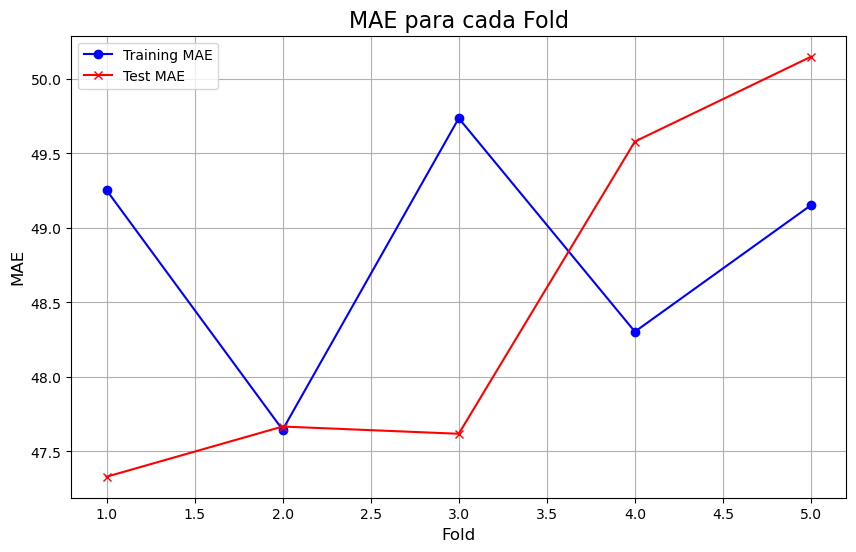

In [166]:
plt.figure(figsize=(10, 6))

plt.plot(range(1, len(mae_train_per_fold) + 1), mae_train_per_fold, marker='o', color='blue', label='Training MAE')
plt.plot(range(1, len(mae_test_per_fold) + 1), mae_test_per_fold, marker='x', color='red', label='Test MAE')

plt.title('MAE para cada Fold', fontsize=16)
plt.xlabel('Fold', fontsize=12)
plt.ylabel('MAE', fontsize=12)

plt.legend()
plt.grid(True)

plt.savefig('rna_tuning_mae_per_fold.png')

plt.show()